In [1]:
import requests
import pandas as pd
import numpy as np
import json
import janitor
import math
from datetime import datetime
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [2]:
def setmyplotstyle():
    #plt.style.use('fivethirtyeight')
    plt.style.use('seaborn-v0_8-pastel')
    #plt.style.use('dark_background')
    plt.rcParams['figure.figsize'] = (22, 8)
    plt.rcParams['font.size'] = 14
    #plt.rcParams['font.family'] = 'sans-serif'
    #plt.rcParams['font.sans-serif'] = 'Helvetica'
    plt.rcParams['axes.facecolor'] = 'white'
    plt.rcParams['figure.facecolor'] = 'white'
    plt.rcParams['axes.grid'] = False
    plt.rcParams['axes.spines.right'] = False
    plt.rcParams['axes.spines.top'] = False
    plt.rcParams['axes.edgecolor'] = 'black'
    plt.rcParams['axes.linewidth'] = 0.8
    plt.rcParams['lines.linewidth'] = 1.5
    plt.rcParams['figure.titleweight'] = 'bold'
setmyplotstyle()

In [3]:
def format_float(value):
    return f'{value:,.2f}'
pd.options.display.float_format = format_float

In [4]:
# functions to clean up dataframe
def strip_clean_drop(dataframe):
    dataframe.columns = dataframe.columns.str.strip()  # gets rid of extra spaces
    dataframe.columns = dataframe.columns.str.lower()  # converts to lower case
    dataframe.columns = dataframe.columns.str.replace(' ', '_')  # allow dot notation with no spaces
    dataframe.columns = dataframe.columns.str.replace("'", '')  # allow dot notation with no special chars
    dataframe.columns = dataframe.columns.str.replace(".", '', regex=False)  # allow dot notation with no special chars
    dataframe = dataframe.dropna(axis=0, how="all")
    dataframe = dataframe.dropna(axis=1, how="all")
    dataframe = dataframe.convert_dtypes(convert_string=True)
    
    try:
        dataframe = dataframe.apply(lambda x: x.str.strip().lower() if x.dtypes=="string" else x)
    except:
        pass
    
    return dataframe

In [5]:
def getToken():
    # get token
    api_url = "https://www.ura.gov.sg/uraDataService/insertNewToken.action"
    headers = {
        'AccessKey':'32417271-1c2e-4a9f-bd17-f97c6ce79c4e',
        'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64; rv:82.0) Gecko/20100101 Firefox/82.0'
    }
    response = requests.get(url=api_url, headers=headers)

    if response.status_code == 200:
        data = json.loads(response.text)
        dailyToken = data['Result']
        #print(response.headers)
        #print(response.text)
    else:
        print(f"Error: {response.status_code}")
        exit()
    
    return dailyToken

TOKEN = getToken()


In [6]:

def loadPipeline():
    api_url = "https://www.ura.gov.sg/uraDataService/invokeUraDS"
    params = {'service': 'PMI_Resi_Pipeline'}
    headers = {
        'AccessKey':'32417271-1c2e-4a9f-bd17-f97c6ce79c4e',
        'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64; rv:82.0) Gecko/20100101 Firefox/82.0',
        'Token':TOKEN
    }
    
    response = requests.get(url=api_url, params=params, headers=headers)
    data = json.loads(response.text)
    data = data['Result']
    df = pd.json_normalize(data)
    
    return df

dfp = loadPipeline()
# clean up
dfp = dfp[dfp['expectedTOPYear']!="na"]
pipeline = (
    dfp.clean_names()
    .convert_dtypes()
    .change_type(['expectedtopyear'],dtype='int',ignore_exception='keep_values')
    .change_type(['street','district','project','developername'],dtype='string')
    .transform_columns(['street','district','project','developername'],lambda x: x.lower(),elementwise=True)
)

/opt/homebrew/Caskroom/miniforge/base/envs/py3.10/lib/python3.10/site-packages/pandas_flavor/register.py:157: FutureWarning: This function will be deprecated in a 1.x release. Please use `pd.DataFrame.astype` instead.
  return method(self._obj, *args, **kwargs)
/opt/homebrew/Caskroom/miniforge/base/envs/py3.10/lib/python3.10/site-packages/pandas_flavor/register.py:157: FutureWarning: This function will be deprecated in a 1.x release. Please use `pd.DataFrame.astype` instead.
  return method(self._obj, *args, **kwargs)


In [7]:
def loadDataBatch(batch_no):
    api_url = "https://www.ura.gov.sg/uraDataService/invokeUraDS"
    params = {'service': 'PMI_Resi_Transaction', 'batch':batch_no}
    headers = {
        'AccessKey':'32417271-1c2e-4a9f-bd17-f97c6ce79c4e',
        'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64; rv:82.0) Gecko/20100101 Firefox/82.0',
        'Token':TOKEN
    }
    
    response = requests.get(url=api_url, params=params, headers=headers)
    data = json.loads(response.text)
    data = data['Result']
    df = pd.json_normalize(data,'transaction',['project','marketSegment','street'])
    
    return df

In [8]:
def getData():
    batch_list = [1,2,3,4]
    dflist = []
    for count, batch in enumerate(batch_list):
        print(batch)
        df = loadDataBatch(batch)
        dflist.append(df)
    c_data = pd.concat(dflist)
    return c_data

In [9]:
df = getData()

1
2
3
4


In [10]:
# clean up
pdata = (
    df.clean_names()
    .convert_dtypes()
    .remove_columns(['nettprice'])
    .change_type(['area','noofunits','typeofsale','price','district'],dtype='float',ignore_exception='keep_values')
    .change_type(['floorrange','contractdate','propertytype','typeofarea','tenure','project','marketsegment','street'],dtype='string')
    .transform_columns(['floorrange','contractdate','propertytype','typeofarea','tenure','project','marketsegment','street'],lambda x: x.lower(),elementwise=True)
    .add_column(column_name='sqft',value=(df['area'].astype('float')*10.764))
)

# transformations
pdata = (
    pdata.transform_columns(['sqft'],lambda x: math.floor(x),elementwise=True)
    .add_column(column_name='pricepersm',value=(pdata['price']/pdata['area']))
    .add_column(column_name='pricepersqft',value=(pdata['price']/pdata['sqft']))
    .add_column(column_name='mth',value=pdata['contractdate'].str[0:2])
    .add_column(column_name='year',value=pdata['contractdate'].str[2:4])
)

pdata = pdata.add_column(column_name='_date',value=("01"+"/"+pdata["mth"]+"/"+pdata["year"]))
pdata = pdata.transform_columns(['_date'], lambda x: datetime.strptime(x, "%d/%m/%y").date(), elementwise=True)
pdata = pdata.change_type(['mth','year'],dtype='int',ignore_exception='keep_values')
pdata["_date"] = pd.to_datetime(pdata["_date"], dayfirst=True, errors="coerce")
pdata = pdata.sort_values('_date')

pdata[['leasep','leaseyear']] = 0
mask = pdata['tenure'].str.contains(" yrs lease commencing from ")
split_data = pdata.loc[mask, 'tenure'].str.split(" yrs lease commencing from ", n=1, expand=True)
pdata.loc[mask, ['leasep', 'leaseyear']] = split_data.values
#pdata['leasep'] = pdata['leasep'].astype('i')
pdata = pdata.change_type(['leasep','leaseyear'],dtype="int",ignore_exception="keep_values")
pdata['remaininglease'] = (pdata['leaseyear'] + pdata['leasep']) - datetime.today().year
pdata['remaininglease'] = pdata['remaininglease'].mask(pdata['remaininglease'] <= 0, pd.NA)

/opt/homebrew/Caskroom/miniforge/base/envs/py3.10/lib/python3.10/site-packages/pandas_flavor/register.py:157: FutureWarning: This function will be deprecated in a 1.x release. Please use `pd.DataFrame.drop` instead.
  return method(self._obj, *args, **kwargs)
/opt/homebrew/Caskroom/miniforge/base/envs/py3.10/lib/python3.10/site-packages/pandas_flavor/register.py:157: FutureWarning: This function will be deprecated in a 1.x release. Please use `pd.DataFrame.astype` instead.
  return method(self._obj, *args, **kwargs)
/opt/homebrew/Caskroom/miniforge/base/envs/py3.10/lib/python3.10/site-packages/pandas_flavor/register.py:157: FutureWarning: This function will be deprecated in a 1.x release. Please use `pd.DataFrame.astype` instead.
  return method(self._obj, *args, **kwargs)
/opt/homebrew/Caskroom/miniforge/base/envs/py3.10/lib/python3.10/site-packages/pandas_flavor/register.py:157: FutureWarning: This function will be deprecated in a 1.x release. Please use `pd.DataFrame.assign` instead

In [11]:
pdata.info()

<class 'pandas.core.frame.DataFrame'>
Index: 132303 entries, 8197 to 8951
Data columns (total 22 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   area            132303 non-null  float64       
 1   floorrange      132303 non-null  object        
 2   noofunits       132303 non-null  float64       
 3   contractdate    132303 non-null  object        
 4   typeofsale      132303 non-null  float64       
 5   price           132303 non-null  float64       
 6   propertytype    132303 non-null  object        
 7   district        132303 non-null  float64       
 8   typeofarea      132303 non-null  object        
 9   tenure          132303 non-null  object        
 10  project         132303 non-null  object        
 11  marketsegment   132303 non-null  object        
 12  street          132303 non-null  object        
 13  sqft            132303 non-null  int64         
 14  pricepersm      132303 non-null  float64

In [12]:
pdata.sample(5)

,area,floorrange,noofunits,contractdate,typeofsale,price,propertytype,district,typeofarea,tenure,...,street,sqft,pricepersm,pricepersqft,mth,year,_date,leasep,leaseyear,remaininglease
13659,129.00,11-15,1.00,0121,3.00,"1,100,000.00",executive condominium,19.00,strata,99 yrs lease commencing from 2001,...,rivervale link,1388,"8,527.13",792.19,1,21,2021-01-01,99,2001,76.00
28189,45.00,06-10,1.00,0220,3.00,"636,000.00",condominium,18.00,strata,99 yrs lease commencing from 2010,...,pasir ris grove,484,"14,133.33","1,313.02",2,20,2020-02-01,99,2010,85.00
13301,86.00,06-10,1.00,1020,1.00,"1,033,000.00",executive condominium,27.00,strata,99 yrs lease commencing from 2018,...,canberra walk,925,"12,011.63","1,115.91",10,20,2020-10-01,99,2018,93.00
8791,64.00,01-05,1.00,0520,1.00,"1,087,000.00",apartment,5.00,strata,99 yrs lease commencing from 2019,...,jalan lempeng,688,"16,984.38","1,577.89",5,20,2020-05-01,99,2019,94.00
18833,72.00,01-05,1.00,0623,1.00,"2,068,000.00",condominium,10.00,strata,freehold,...,leedon heights,775,"28,722.22","2,668.36",6,23,2023-06-01,0,0,NaN


In [13]:
d_ignorelist = [7,8,17,18,22,19,25,26,27]
base_query = ' propertytype != "executive condominium" & year >= 23 & (sqft >= 517 & sqft < 1000 ) & pricepersqft <=2000 '
g4 = pdata.query(f'district not in @d_ignorelist & typeofsale == 2 & {base_query}',engine='python')\
    .groupby(['district'])\
    .agg(
    _count=('noofunits',np.sum),
    _minprice_sqft=('pricepersqft',np.min),
    _meanprice_sqft=('pricepersqft',np.mean),
    _maxprice_sqft=('pricepersqft',np.max),
    _maxgrossprice=('price',np.max),
    _minsqft=('sqft',np.min),
    _maxsqft=('sqft',np.max)
).sort_values(by='_maxprice_sqft')
display(g4)

/var/folders/zx/760hzdz94cx_t0lcw9msph_80000gn/T/ipykernel_60022/1506664555.py:3: FutureWarning: The provided callable <function sum at 0x108849480> is currently using SeriesGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  g4 = pdata.query(f'district not in @d_ignorelist & typeofsale == 2 & {base_query}',engine='python')\
/var/folders/zx/760hzdz94cx_t0lcw9msph_80000gn/T/ipykernel_60022/1506664555.py:3: FutureWarning: The provided callable <function amin at 0x108849ea0> is currently using SeriesGroupBy.min. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "min" instead.
  g4 = pdata.query(f'district not in @d_ignorelist & typeofsale == 2 & {base_query}',engine='python')\
/var/folders/zx/760hzdz94cx_t0lcw9msph_80000gn/T/ipykernel_60022/1506664555.py:3: FutureWarning: The provided callable <function mean at 0x10884a8c0> is cu

,_count,_minprice_sqft,_meanprice_sqft,_maxprice_sqft,_maxgrossprice,_minsqft,_maxsqft
district,,,,,,,
15.00,1.00,"1,594.59","1,594.59","1,594.59","1,150,000.00",721,721
20.00,3.00,"1,935.46","1,947.18","1,962.72","1,750,000.00",527,904
12.00,35.00,"1,653.86","1,836.55","1,990.76","1,780,000.00",570,979
13.00,69.00,"1,693.22","1,907.40","1,992.69","1,550,000.00",613,796
3.00,2.00,"1,900.78","1,947.72","1,994.67","1,534,500.00",731,807
23.00,4.00,"1,740.67","1,873.08","1,995.49","1,910,000.00",624,990
21.00,13.00,"1,882.93","1,967.19","1,998.81","1,790,000.00",592,904
14.00,27.00,"1,670.15","1,910.00","1,999.76","1,920,000.00",527,979
5.00,104.00,"1,569.73","1,917.28","1,999.98","1,908,000.00",527,990


In [14]:
fig = px.bar(g4, y="_meanprice_sqft", text_auto=True,title='psf median of subsale from 2022 to date')
fig.show()

In [15]:
pdata.query(f' typeofsale == 2 & {base_query}',engine='python')\
    .groupby(['project'])\
    .agg(
    _count=('noofunits',np.sum),
    _minprice_sqft=('pricepersqft',np.min),
    _meanprice_sqft=('pricepersqft',np.mean),
    _maxprice_sqft=('pricepersqft',np.max),
    _maxgrossprice=('price',np.max),
    _minsqft=('sqft',np.min),
    _maxsqft=('sqft',np.max)
).sort_values(by='_maxprice_sqft')

/var/folders/zx/760hzdz94cx_t0lcw9msph_80000gn/T/ipykernel_60022/3063012740.py:1: FutureWarning:

The provided callable <function sum at 0x108849480> is currently using SeriesGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.

/var/folders/zx/760hzdz94cx_t0lcw9msph_80000gn/T/ipykernel_60022/3063012740.py:1: FutureWarning:

The provided callable <function amin at 0x108849ea0> is currently using SeriesGroupBy.min. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "min" instead.

/var/folders/zx/760hzdz94cx_t0lcw9msph_80000gn/T/ipykernel_60022/3063012740.py:1: FutureWarning:

The provided callable <function mean at 0x10884a8c0> is currently using SeriesGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.

/var/folders/zx/760hzdz94cx_t0lcw

,_count,_minprice_sqft,_meanprice_sqft,_maxprice_sqft,_maxgrossprice,_minsqft,_maxsqft
project,,,,,,,
the jovell,3.00,"1,338.24","1,450.94","1,554.69","1,210,000.00",527,904
sycamore tree,1.00,"1,594.59","1,594.59","1,594.59","1,150,000.00",721,721
tedge,1.00,"1,670.15","1,670.15","1,670.15","1,600,000.00",957,957
rezi 24,2.00,"1,694.10","1,698.65","1,703.21","1,100,000.00",548,645
the watergardens at canberra,2.00,"1,648.65","1,685.51","1,722.38","1,168,000.00",678,678
phoenix residences,1.00,"1,740.67","1,740.67","1,740.67","1,292,820.00",742,742
the essence,5.00,"1,300.63","1,537.06","1,761.94","1,340,000.00",538,818
noma,1.00,"1,763.97","1,763.97","1,763.97","1,500,000.00",850,850
dairy farm residences,1.00,"1,827.43","1,827.43","1,827.43","1,140,888.00",624,624


In [16]:
g1 = pdata.query('project.str.contains("euhabitat") & area==49',engine='python').groupby(['_date','area','floorrange']).agg(
    _count=('noofunits',np.sum),
    _minprice_sqft=('pricepersqft',np.min),
    _meanprice_sqft=('pricepersqft',np.mean),
    _maxprice_sqft=('pricepersqft',np.max),
    _maxgrossprice=('price',np.max)
).sort_values(by='_date',ascending=False)
g1


/var/folders/zx/760hzdz94cx_t0lcw9msph_80000gn/T/ipykernel_60022/3625477059.py:1: FutureWarning:

The provided callable <function sum at 0x108849480> is currently using SeriesGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.

/var/folders/zx/760hzdz94cx_t0lcw9msph_80000gn/T/ipykernel_60022/3625477059.py:1: FutureWarning:

The provided callable <function amin at 0x108849ea0> is currently using SeriesGroupBy.min. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "min" instead.

/var/folders/zx/760hzdz94cx_t0lcw9msph_80000gn/T/ipykernel_60022/3625477059.py:1: FutureWarning:

The provided callable <function mean at 0x10884a8c0> is currently using SeriesGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.

/var/folders/zx/760hzdz94cx_t0lcw

,,,_count,_minprice_sqft,_meanprice_sqft,_maxprice_sqft,_maxgrossprice
_date,area,floorrange,,,,,
2024-07-01,49.00,01-05,2.00,"1,374.57","1,388.79","1,403.01","740,000.00"
2024-06-01,49.00,01-05,1.00,"1,403.01","1,403.01","1,403.01","740,000.00"
2024-03-01,49.00,01-05,1.00,"1,380.26","1,380.26","1,380.26","728,000.00"
2024-02-01,49.00,01-05,1.00,"1,431.45","1,431.45","1,431.45","755,000.00"
2023-10-01,49.00,01-05,2.00,"1,421.97","1,437.28","1,452.59","766,150.00"
2023-07-01,49.00,01-05,1.00,"1,444.73","1,444.73","1,444.73","762,000.00"
2023-06-01,49.00,01-05,1.00,"1,403.01","1,403.01","1,403.01","740,000.00"
2023-05-01,49.00,01-05,2.00,"1,384.05","1,403.01","1,421.97","750,000.00"
2023-04-01,49.00,01-05,2.00,"1,384.05","1,412.49","1,440.93","760,000.00"


In [17]:
g1 = pdata.query('district==15 & area==49 & year>=20',engine='python').groupby(['_date','project']).agg(
    _count=('noofunits',np.sum),
    _minprice_sqft=('pricepersqft',np.min),
    _meanprice_sqft=('pricepersqft',np.mean),
    _maxprice_sqft=('pricepersqft',np.max),
    _maxgrossprice=('price',np.max)
).sort_values(by='_date',ascending=False)
g1


/var/folders/zx/760hzdz94cx_t0lcw9msph_80000gn/T/ipykernel_60022/2191467994.py:1: FutureWarning:

The provided callable <function sum at 0x108849480> is currently using SeriesGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.

/var/folders/zx/760hzdz94cx_t0lcw9msph_80000gn/T/ipykernel_60022/2191467994.py:1: FutureWarning:

The provided callable <function amin at 0x108849ea0> is currently using SeriesGroupBy.min. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "min" instead.

/var/folders/zx/760hzdz94cx_t0lcw9msph_80000gn/T/ipykernel_60022/2191467994.py:1: FutureWarning:

The provided callable <function mean at 0x10884a8c0> is currently using SeriesGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.

/var/folders/zx/760hzdz94cx_t0lcw

_count  _minprice_sqft  _meanprice_sqft  \
_date      project                                                        
2024-08-01 tembusu grand          1.00        2,677.10         2,677.10   
2024-07-01 tembusu grand          3.00        2,578.51         2,593.68   
2024-06-01 tembusu grand          2.00        2,548.18         2,555.76   
           suites @ guillemard    1.00        1,518.67         1,518.67   
2024-05-01 tembusu grand          1.00        2,652.45         2,652.45   
2024-04-01 the vanderlint         1.00        1,611.57         1,611.57   
2023-10-01 tembusu grand          1.00        2,517.84         2,517.84   
2023-08-01 questa @ dunman        1.00        1,687.41         1,687.41   
2023-07-01 tembusu grand          2.00        2,610.74         2,700.80   
           sycamore tree          1.00        1,592.61         1,592.61   
2023-06-01 tembusu grand          3.00        2,426.83         2,533.01   
2023-05-01 tembusu grand          5.00        2,409.77         2,523.91   
2023-04-01 tembusu grand         75.00        2,366.16         2,502.37   
2023-03-01 straits residences     1.00        1,645.70         1,645.70   
2022-10-01 the silver fir         1.00        1,554.69         1,554.69   
2022-07-01 questa @ dunman        1.00        1,676.03         1,676.03   
2022-04-01 questa @ dunman        1.00        1,554.69         1,554.69   
2022-01-01 suites @ guillemard    1.00        1,459.89         1,459.89   
2021-05-01 parc bleu              1.00        1,289.26         1,289.26   
2021-04-01 the silver fir         1.00        1,440.93         1,440.93   
2021-01-01 straits residences     1.00        1,365.09         1,365.09   
2020-09-01 prestige loft          1.00        1,260.82         1,260.82   
2020-04-01 parc bleu              1.00        1,190.67         1,190.67   

                                _maxprice_sqft  _maxgrossprice  
_date      project                                              
2024-08-01 tembusu grand              2,677.10    1,412,000.00  
2024-07-01 tembusu grand              2,608.85    1,376,000.00  
2024-06-01 tembusu grand              2,563.34    1,352,000.00  
           suites @ guillemard        1,518.67      801,000.00  
2024-05-01 tembusu grand              2,652.45    1,399,000.00  
2024-04-01 the vanderlint             1,611.57      850,000.00  
2023-10-01 tembusu grand              2,517.84    1,328,000.00  
2023-08-01 questa @ dunman            1,687.41      890,000.00  
2023-07-01 tembusu grand              2,790.86    1,472,000.00  
           sycamore tree              1,592.61      840,000.00  
2023-06-01 tembusu grand              2,730.19    1,440,000.00  
2023-05-01 tembusu grand              2,709.33    1,429,000.00  
2023-04-01 tembusu grand              2,669.52    1,408,000.00  
2023-03-01 straits residences         1,645.70      868,000.00  
2022-10-01 the silver fir             1,554.69      820,000.00  
2022-07-01 questa @ dunman            1,676.03      884,000.00  
2022-04-01 questa @ dunman            1,554.69      820,000.00  
2022-01-01 suites @ guillemard        1,459.89      770,000.00  
2021-05-01 parc bleu                  1,289.26      680,000.00  
2021-04-01 the silver fir             1,440.93      760,000.00  
2021-01-01 straits residences         1,365.09      720,000.00  
2020-09-01 prestige loft              1,260.82      665,000.00  
2020-04-01 parc bleu                  1,190.67      628,000.00

In [18]:
pdata.query("typeofsale==1 & area==46").groupby(['marketsegment','_date']).agg(
    _count=('noofunits',np.sum),
    _meanprice_sqft=('pricepersqft',np.mean),
    _maxprice_sqft=('pricepersqft',np.max),
    _maxgrossprice=('price',np.max)
)

/var/folders/zx/760hzdz94cx_t0lcw9msph_80000gn/T/ipykernel_60022/464253726.py:1: FutureWarning:

The provided callable <function sum at 0x108849480> is currently using SeriesGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.

/var/folders/zx/760hzdz94cx_t0lcw9msph_80000gn/T/ipykernel_60022/464253726.py:1: FutureWarning:

The provided callable <function mean at 0x10884a8c0> is currently using SeriesGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.

/var/folders/zx/760hzdz94cx_t0lcw9msph_80000gn/T/ipykernel_60022/464253726.py:1: FutureWarning:

The provided callable <function amax at 0x108849cf0> is currently using SeriesGroupBy.max. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "max" instead.



_count  _meanprice_sqft  _maxprice_sqft  \
marketsegment _date                                                 
ccr           2019-09-01    1.00         2,377.09        2,377.09   
              2019-12-01    1.00         2,801.21        2,801.21   
              2020-01-01    3.00         2,928.89        3,019.32   
              2020-02-01    3.00         2,460.83        2,599.04   
              2020-07-01    1.00         2,475.64        2,475.64   
...                          ...              ...             ...   
rcr           2024-02-01    1.00         2,928.44        2,928.44   
              2024-03-01    2.00         2,902.76        2,907.19   
              2024-04-01    2.00         2,963.71        3,035.32   
              2024-05-01    3.00         3,081.93        3,100.11   
              2024-06-01    1.00         3,059.72        3,059.72   

                          _maxgrossprice  
marketsegment _date                       
ccr           2019-09-01    1,177,000.00  
              2019-12-01    1,387,000.00  
              2020-01-01    1,495,000.00  
              2020-02-01    1,286,900.00  
              2020-07-01    1,225,800.00  
...                                  ...  
rcr           2024-02-01    1,450,000.00  
              2024-03-01    1,439,480.00  
              2024-04-01    1,502,922.00  
              2024-05-01    1,535,000.00  
              2024-06-01    1,515,000.00  

[89 rows x 4 columns]

/var/folders/zx/760hzdz94cx_t0lcw9msph_80000gn/T/ipykernel_60022/1374957873.py:1: FutureWarning:

The provided callable <function sum at 0x108849480> is currently using SeriesGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.

/var/folders/zx/760hzdz94cx_t0lcw9msph_80000gn/T/ipykernel_60022/1374957873.py:1: FutureWarning:

The provided callable <function mean at 0x10884a8c0> is currently using SeriesGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.

/var/folders/zx/760hzdz94cx_t0lcw9msph_80000gn/T/ipykernel_60022/1374957873.py:1: FutureWarning:

The provided callable <function amax at 0x108849cf0> is currently using SeriesGroupBy.max. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "max" instead.



<Axes: xlabel='floorrange,sqft,_date,typeofsale'>

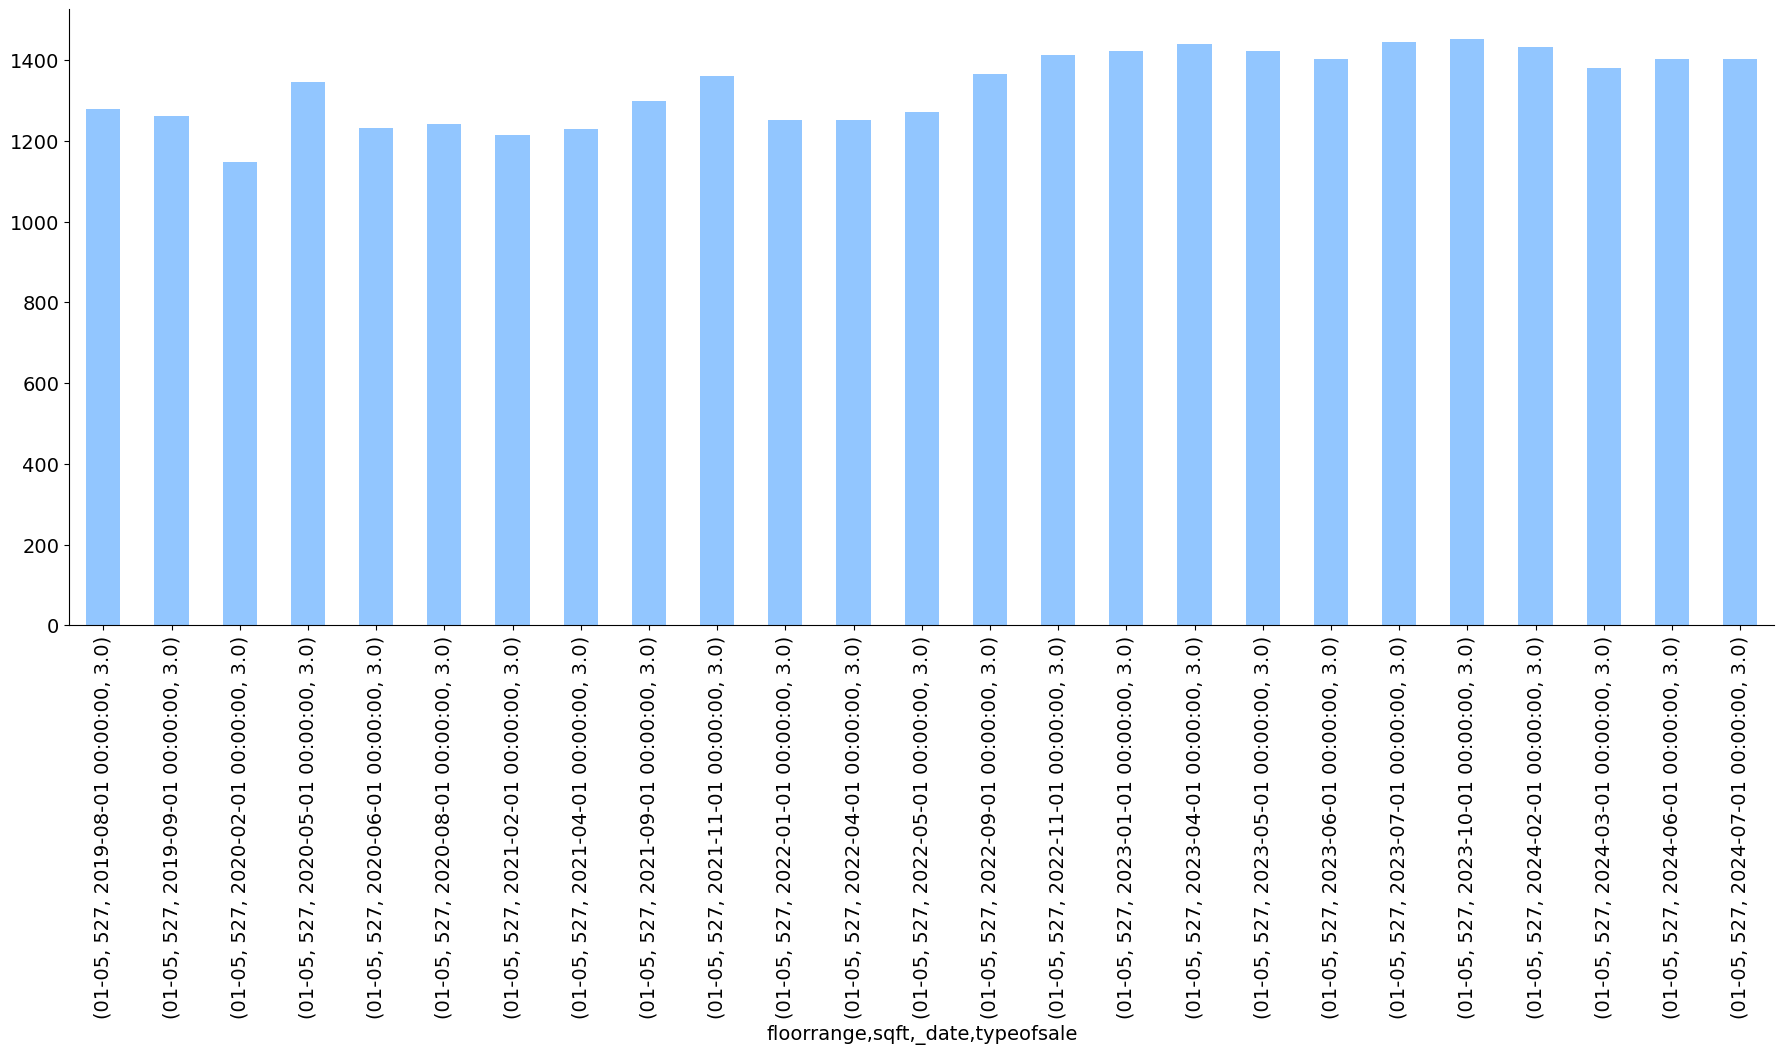

In [19]:
pdata.query('project.str.contains("euhabitat") & sqft==527 & year>=18').groupby(['floorrange','sqft','_date','typeofsale']).agg(
    _count=('noofunits',np.sum),
    _meanprice_sqft=('pricepersqft',np.mean),
    _maxprice_sqft=('pricepersqft',np.max),
    _maxgrossprice=('price',np.max)
)._maxprice_sqft.plot.bar()

In [20]:
g1 = pdata.query('project.str.contains("euhabitat") & sqft==527 & year>=18').groupby(['_date']).agg(
    _count=('noofunits',np.sum),
    _meanprice_sqft=('pricepersqft',np.mean),
    _maxprice_sqft=('pricepersqft',np.max),
    _maxgrossprice=('price',np.max)
)#._maxprice_sqft.plot.bar()

/var/folders/zx/760hzdz94cx_t0lcw9msph_80000gn/T/ipykernel_60022/1071205739.py:1: FutureWarning:

The provided callable <function sum at 0x108849480> is currently using SeriesGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.

/var/folders/zx/760hzdz94cx_t0lcw9msph_80000gn/T/ipykernel_60022/1071205739.py:1: FutureWarning:

The provided callable <function mean at 0x10884a8c0> is currently using SeriesGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.

/var/folders/zx/760hzdz94cx_t0lcw9msph_80000gn/T/ipykernel_60022/1071205739.py:1: FutureWarning:

The provided callable <function amax at 0x108849cf0> is currently using SeriesGroupBy.max. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "max" instead.



In [21]:
fig = px.bar(g1, y="_meanprice_sqft", text_auto=True)
fig.show()